# LTUH apertures

Extracted from:

https://docs.google.com/spreadsheets/d/1gA0nmOZLVUzkSr6bBm0YMzfWX3KUkwwDyv8X70UX9nY/edit#gid=0

In [1]:
# Useful for debugging
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%config InlineBackend.figure_format = 'retina'

in2m = 0.0254

In [2]:
df = pd.read_csv('LTU_apertures.csv')

<AxesSubplot:>

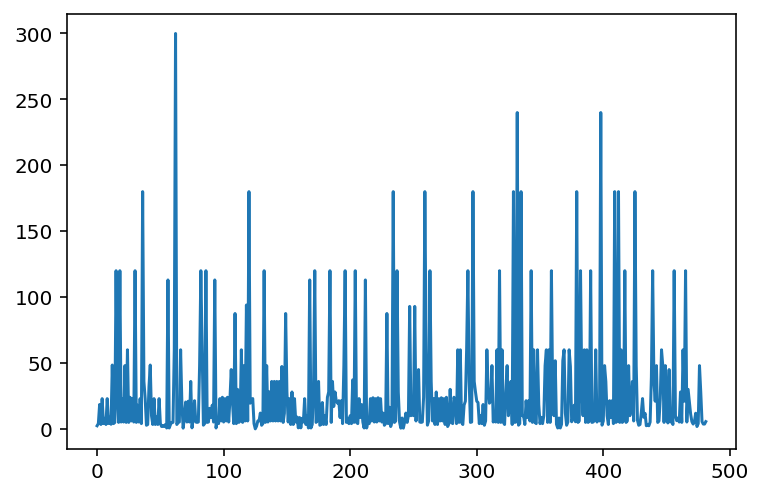

In [3]:
df['length(in)'].plot()

In [4]:
# Non-round
df[df['shape'] != 'round']

,description,mad_name,z_start(m),length(in),beamline,shape,round_diameter(in),elliptical_diameter_x(in),elliptical_diameter_y(in)
56,Magnet Chamber,BX31*,3255.420,113.00,LTUH,rectangular,NaN,1.402,0.468
93,Vacuum Chamber,NaN,3284.256,113.00,LTUH,rectangular,NaN,1.402,0.468
109,*R56 Chicane Asmby,"BCX321*,BCX322*,BCX323*,BCX324*,",3292.700,87.54,LTUH,rectangular,NaN,0.553,2.756
149,R56 Chicane ASSY,"BCX351*,BCX52*,BCX353*,BCX354*",3320.028,87.54,LTUH,rectangular,NaN,0.553,2.756
168,Magnet Chamber**,BX35*,3327.045,113.00,LTUH,rectangular,NaN,1.402,0.468
212,Magnet Chamber,BX36*,3355.857,113.00,LTUH,rectangular,NaN,1.402,0.468
229,R56 Chicane ASSY,"BX361*,BX362*,BX363*,BX364*",3363.137,87.54,LTUH,rectangular,NaN,0.553,2.756


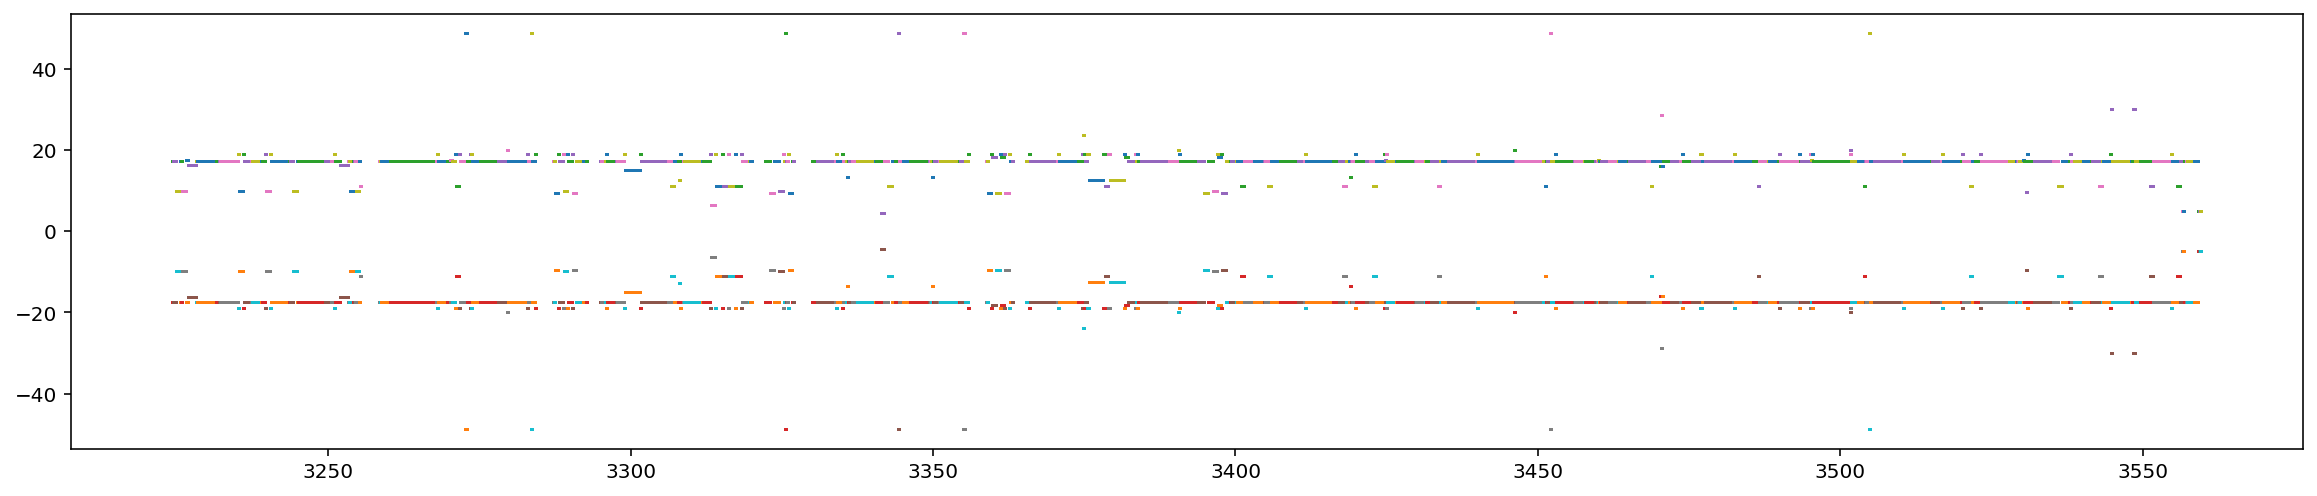

In [5]:
# Plot round

df2 = df[df['shape'] == 'round']

z0 = df2['z_start(m)']
z1 = df2['z_start(m)'] + df2['length(in)']*in2m
r  = df2['round_diameter(in)'] * in2m/2 * 1000

fig, ax = plt.subplots(figsize=(20,4))

for a, b, c in zip(z0, z1, r):
    ax.plot([a, b], [c, c])
    ax.plot([a, b], [-c, -c])

In [6]:
# Riffle to make plot
def riffle(a, b):
    c = np.empty((a.size + b.size,), dtype=a.dtype)
    c[0::2] = a
    c[1::2] = b
    return c

X = riffle(z0, z1)
Y = riffle(r, r)

Text(0, 0.5, 'Radius (mm)')

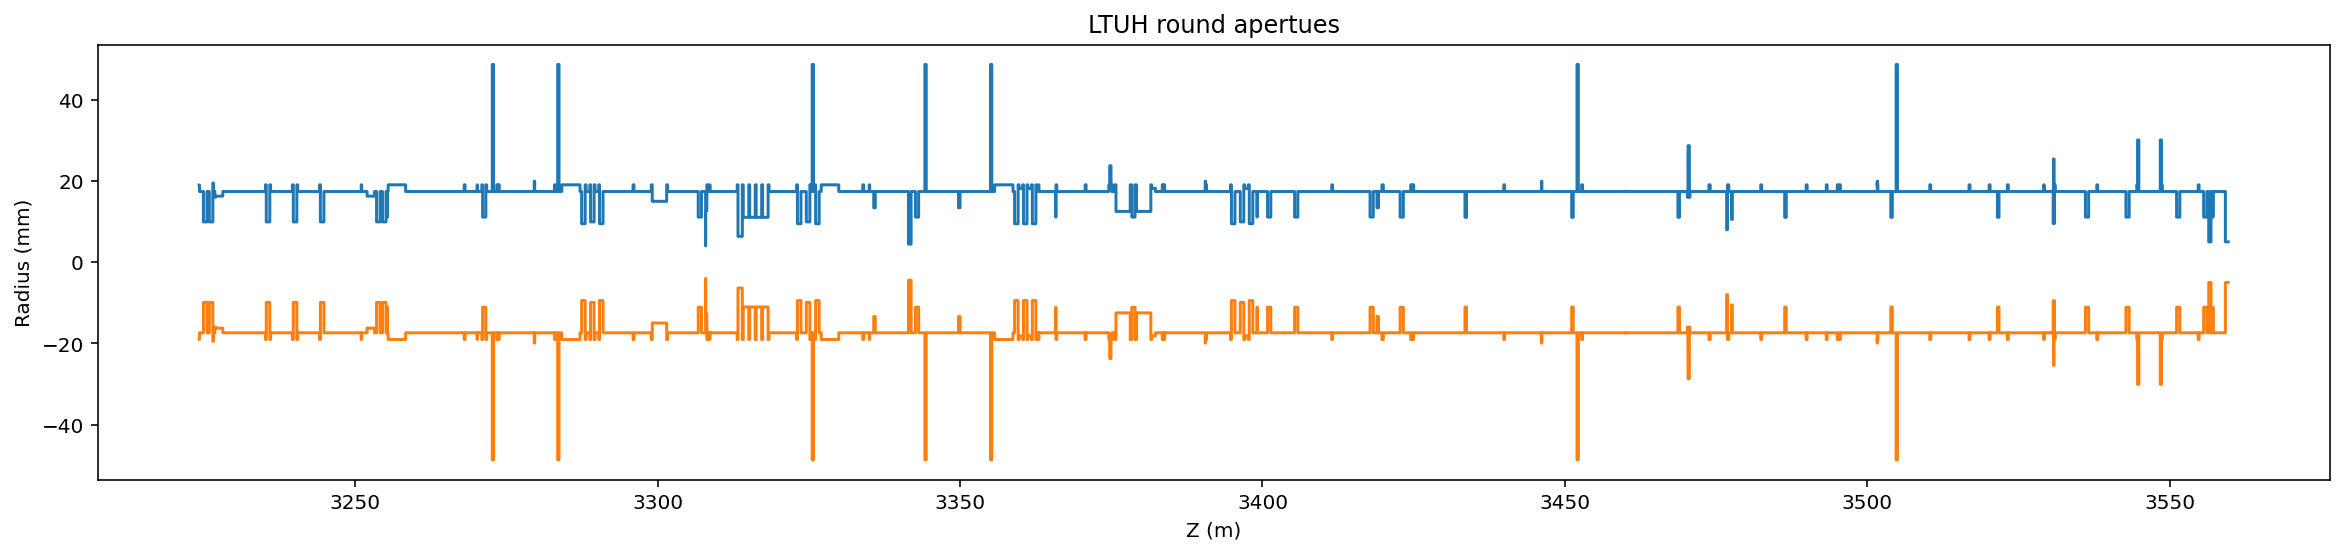

In [7]:
fig, ax = plt.subplots(figsize=(20,4))

ax.plot(X, Y)
ax.plot(X, -Y)

#ax.set_xlim(3250, 3300)
ax.set_title('LTUH round apertues')
ax.set_xlabel('Z (m)')
ax.set_ylabel('Radius (mm)', color='black')

# Tao to make `apertures_ltuh.bmad`

In [8]:
from pytao import TaoModel
?M.evaluate


Object `M.evaluate` not found.


In [9]:
M = TaoModel('$LCLS_LATTICE/bmad/models/cu_hxr/tao.init', ploton=False)


def lat_names(match='*'):
    return np.array(M.cmd(f'python lat_list -track_only >>{match}|model ele.name'))
ele_names = lat_names('*')
drift_names = lat_names('drift::*')

Initialized Tao with /var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmpr_aq_3qt/tao/tao.init


In [10]:
ele_s = np.array(M.cmd('python lat_list -track_only >>*|model ele.s')).astype('float')
len(ele_s), ele_s

(2990,
 array([ 0.00000000e+00, -8.69048000e-01,  0.00000000e+00, ...,
         1.75088308e+03,  1.75088308e+03,  1.75088308e+03]))

In [11]:
ix_ref = ele_names.tolist().index('BEGLTUH')
ix_ref, ele_s[ix_ref]

(1646, 1209.35708508099)

In [12]:
floor_z = np.array(M.evaluate('lat::floor.z[beginning:end]'))
len(floor_z), floor_z[ix_ref], ele_s[ix_ref]

(2990, 3224.02242303644, 1209.35708508099)

In [13]:
# Double check
np.interp(3224.02242303644, floor_z, ele_s)

1209.35708508099

In [14]:
def marker_ele(z, x1, shape='round', y1=None, x2=None, y2=None, ref_ele='BEGLTUH'):
    """
    Makes a marker element at a Z floor location
    
    """
    
    # Fill in symmetric parts
    if x2 is None:
        x2 = x1
    if y1 is None:
        y1 = x1        
    if y2 is None:
        y2 = y1

    
    # Find s
    s = np.interp(z, floor_z, ele_s)
    
    ix_ref = ele_names.tolist().index(ref_ele)
    s_ref = ele_s[ix_ref]
    
    name = f'aperture_z_{np.around(z, 6)}_m'
    if shape == 'round':
        aperture_type = 'elliptical'
    elif shape == 'rectangular':
        aperture_type = shape
    else:
        raise
    
    ele = f"""{name}: marker, superimpose, ref = {ref_ele}, offset = {s - s_ref},
    x1_limit={x1}, x2_limit={x2}, y1_limit={y1}, y2_limit={y2},
    aperture_type = {aperture_type}
    """
    
    return name, ele
RES = marker_ele( 3224.02242303644, 1, 'round')
print(RES[1])

aperture_z_3224.022423_m: marker, superimpose, ref = BEGLTUH, offset = 0.0,
    x1_limit=1, x2_limit=1, y1_limit=1, y2_limit=1,
    aperture_type = elliptical
    


In [15]:
# Loop over the table

ELE = {}


MIN_SPACING = 2.0 # sub-slice if length is longer than this.

for index, row in df.iterrows():
    
    z0 = row['z_start(m)']
    L = row['length(in)']*in2m
    z1 = row['z_start(m)'] + L
    
    n_apertures = int(max(np.ceil(L/MIN_SPACING), 2))
    
    #print(n_apertures, L)
    shape = row['shape']
    zlist = np.linspace(z0, z1, n_apertures)
     
    
    for z in zlist:
 #   print(zlist)
        if shape == 'round':
            x1 = row['round_diameter(in)']*in2m / 2
            y1 = x1
        elif shape == 'rectangular':
            x1 = row['elliptical_diameter_x(in)']*in2m/2
            y1 = row['elliptical_diameter_y(in)']*in2m/2
            
        x1 = np.around(x1, 9) # Round to nm
        y1 = np.around(y1, 9)
        name, ele = marker_ele(z, x1, y1=y1, shape=shape)
        ELE[name] = ele
list(ELE)[0:10]

['aperture_z_3224.15_m',
 'aperture_z_3224.209944_m',
 'aperture_z_3224.21_m',
 'aperture_z_3224.3116_m',
 'aperture_z_3224.312_m',
 'aperture_z_3224.7819_m',
 'aperture_z_3224.782_m',
 'aperture_z_3224.866836_m',
 'aperture_z_3224.867_m',
 'aperture_z_3225.449676_m']

In [16]:
len(ELE)

894

In [17]:
# write
with open('apertures_ltuh.bmad', 'w') as f:
    for name, ele in ELE.items():
        f.write(ele)
        f.write('\n')

# Alternative: find nearest elements

In [ ]:
from pytao.util.lattice_element import lat_element
ELE = lat_element(1, 0, 100, 'model', M)
ELE.params['key']

In [ ]:
ele_L = np.array(M.cmd('python lat_list -track_only >>*|model ele.l')).astype('float')
ele_s0 = ele_s - ele_L

In [ ]:
# Check if any apertures are set
np.any(M.evaluate('lat::element_attrib.x1_limit[drift::*]') >0)

In [ ]:
def eles_between(s0, s1):
    """
    Get elements with overlap between s0 and s1. Only return full (unsplit) elements
    """
    inside = np.where(np.logical_and(ele_s0<=s1, ele_s>=s0))
    names = ele_names[inside]
   
    # Filter for drifts
    names = [name for name in names if name in drift_names]
    # Only full elemets
    full_names = list(set([name.split('#')[0] for name in names]))
    
    return full_names
    
eles_between(10,20)

In [ ]:
# Loop over the table

ELE = {}


for index, row in df.iterrows():
    
    z0 = row['z_start(m)']
    L = row['length(in)']*in2m
    z1 = row['z_start(m)'] + L
    
    # Get s
    s0 = np.interp(z0, floor_z, ele_s)
    s1 = np.interp(z1, floor_z, ele_s)
    
    enames = eles_between(s0, s1)
    
    #print(n_apertures, L)
    shape = row['shape']
    if shape == 'round':
        x1 = row['round_diameter(in)']*in2m / 2
        y1 = x1
    elif shape == 'rectangular':
        x1 = row['elliptical_diameter_x(in)']*in2m/2
        y1 = row['elliptical_diameter_y(in)']*in2m/2

    for name in enames:
        if name not in ELE:
            ELE[name] = {'x1':[], 'y1':[]}
        ELE[name]['x1'].append(x1)
        ELE[name]['y1'].append(y1)
ELE

In [ ]:
# Get thick eles only
ix_thick = np.where(ele_L != 0)

In [ ]:
THICK_NAMES = ele_names[ix_thick]
Z = floor_z[ix_thick]

In [ ]:
ELE = {}
for name, z in zip(THICK_NAMES, Z):
    
    name = name.split('#')[0]
    
    ele = {'z':z, 'name':name, 'apertures':[]}
    ELE[name] = ele
# Convert to list
ELE = [ELE[name] for name in ELE]
len(ELE)

In [ ]:
ix_closest = np.where(Z - 3235 > 0)[0][0]

In [ ]:
THICK_NAMES[ix_closest]

In [ ]:

def nearest_ele(z):
    ix_closest = np.where(Z - z > 0)[0][0]
    name = THICK_NAMES[ix_closest].split('#')[0]
    return name

v_nearest_ele = np.vectorize(nearest_ele)

In [ ]:
df['inside_ele'] = v_nearest_ele(df['z_start(m)'])

In [ ]:
df.groupby('inside_ele')

In [ ]:
nearest_ele(3400)

In [ ]:
# Collect consecutive apertures
ap1 = (0,0,0)
z1 = 0
APER = []
for index, row in df.iterrows():
    z0 = np.around(row['z_start(m)'], 9)
    shape = row['shape']
    if shape == 'round':
        x1 = row['round_diameter(in)']*in2m / 2
        y1 = x1
    elif shape == 'rectangular':
        x1 = row['elliptical_diameter_x(in)']*in2m/2
        y1 = row['elliptical_diameter_y(in)']*in2m/2    
    x1 = np.around(x1, 9)
    y1 = np.around(y1, 9)
    
    # This will be the basic aperture
    aper = (shape, x1, y1)
    
    if aper != ap1:
        # New aperture
        APER.append([z0, ap1])
        ap1 = aper

APER=APER[1:]
len(APER)

In [ ]:
aix = 0
ap = APER[aix]
z0 = ap[0]
print(z0)
for ele in ELE:
    z = ele['z']
    
    dz = z - z0
    while dz >= 0 :
        ele['apertures'].append(ap)
        aix += 1
        
    
    
        
    
    
    
    
    

In [ ]:

ELE = {}

for index, row in df.iterrows():
    
    z0 = row['z_start(m)']
    L = row['length(in)']*in2m
    z1 = row['z_start(m)'] + L
    
    n_apertures = int(max(np.ceil(L/MIN_SPACING), 2))
    
    #print(n_apertures, L)
    shape = row['shape']
    zlist = np.linspace(z0, z1, 2)
     
    
    for z in zlist:
        name = nearest_ele(z).split('#')[0]
        if name not in ELE:
            ELE[name] = []

 #   print(zlist)
        if shape == 'round':
            x1 = row['round_diameter(in)']*in2m / 2
            y1 = x1
        elif shape == 'rectangular':
            x1 = row['elliptical_diameter_x(in)']/2
            y1 = row['elliptical_diameter_y(in)']/2
            
        x1 = np.around(x1, 9) # Round to nm
        y1 = np.around(y1, 9)
        
   #     print(name, x1, y1)
        data = (shape, x1, y1)
        ELE[name].append(data)

In [ ]:
set(ELE['DYCVM1'])

In [ ]:
for name, data in ELE.items():
    
    vals = set(data)
    if len(vals) > 1:
        if list(vals)[0] == 'rectangular':
            continue
        rlist = [v[1] for v in list(vals)]
        
        line = f'{name:20}'
        for r in rlist:
            line += f'{1000*r:10.0f}'
        print(line)
        #print(name, *rlist)
    

In [ ]:
%%tao
sho ele DQECA